**Study A — Population-Level Temporal Modeling**

Models: Linear Regression baseline + ARIMA baseline + Population LSTM

Input:  brfss_state_year_agg_FINAL.csv (~317 rows, 50 states × 6 years)

Target: FREQ_DISTRESS — state-level prevalence rate of frequent mental distress

Author: Gia Nguyen

In [1]:
# CELL 1 — Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install pmdarima -q      # for auto ARIMA
!pip install plotly -q        # for choropleth map

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import pmdarima as pm

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_PATH = "/content/drive/MyDrive/BRFSS_Project"
print("Setup complete.")



Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.2 MB/s eta 0:00:00
Setup complete.


In [2]:
# CELL 2 — Load & Inspect State-Year Aggregate

df_agg = pd.read_csv(f"{PROJECT_PATH}/clean_data/brfss_state_year_agg_FINAL.csv")

print(f"Shape: {df_agg.shape}")
print(f"Years: {sorted(df_agg['SURVEY_YEAR'].unique())}")
print(f"States: {df_agg['_STATE'].nunique()}")
print(f"\nColumns:\n{list(df_agg.columns)}")
print(f"\nFREQ_DISTRESS stats:")
print(df_agg['FREQ_DISTRESS'].describe())
print(f"\nSample (first 5 rows):")
print(df_agg[['_STATE','SURVEY_YEAR','FREQ_DISTRESS','MENTHLTH',
               'CURRENT_SMOKER','DEPRESSION_DX']].head())


Shape: (317, 31)
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
States: 54

Columns:
['_STATE', 'SURVEY_YEAR', 'FREQ_DISTRESS', 'MENTHLTH', 'PHYSHLTH', 'POOR_GENHLTH', 'PHYS_INACTIVE', 'CURRENT_SMOKER', 'BINGE_DRINK', 'HEAVY_DRINK', 'OVERWEIGHT_OBESE', 'MARIJAN1', 'DEPRESSION_DX', 'DIABETES', 'HEART_ATTACK', 'STROKE', 'COPD', 'ARTHRITIS', 'NO_AFFORD_DR', 'CHECKUP_RECENT', 'HAS_DOCTOR', 'FOOD_STAMPS', 'HARDSHIP_ANY', 'FOOD_INSECURE', 'LOW_EMOTIONAL_SUPPORT', 'LIFE_DISSATISFIED', 'ACE_SCORE', 'ACE_HH_DYSFUNCTION', 'ACEADSAF_BIN', 'ACEADNED_BIN', 'N_RESPONDENTS']

FREQ_DISTRESS stats:
count    317.000000
mean       0.131569
std        0.019908
min        0.076192
25%        0.118460
50%        0.130695
75%        0.143250
max        0.193152
Name: FREQ_DISTRESS, dtype: float64

Sample (first 5 rows):
   _STATE  SURVEY_YEAR  FREQ_DISTRESS  MENTHLTH  CURRENT_SMOKER  DEPRESSION_DX
0     1.0         2019       0.150246  4.745738        

In [4]:
# CELL 3 — Data Preparation for Study A

# ── Define features for population LSTM ──────────────────────────────────────
# These are the Tier 1 + Tier 2 features from the Study A variable guide
# Only use features available for ALL 6 years (NaN-safe via masking for others)

FEATURE_COLS = [
    # Behavioral (all 6 years)
    'PHYS_INACTIVE', 'CURRENT_SMOKER', 'BINGE_DRINK', 'HEAVY_DRINK',
    'OVERWEIGHT_OBESE',
    # Physical health (all 6 years)
    'POOR_GENHLTH', 'DEPRESSION_DX', 'DIABETES', 'HEART_ATTACK',
    'STROKE', 'COPD', 'ARTHRITIS',
    # Healthcare access (all 6 years after harmonization)
    'NO_AFFORD_DR', 'CHECKUP_RECENT', 'HAS_DOCTOR',
    # Food security (5/6 years — NaN for 2020)
    'FOOD_STAMPS',
    # ACE burden (all 6 years)
    'ACE_SCORE', 'ACE_HH_DYSFUNCTION',
    # Economic hardship (2022-2024 only — NaN for earlier, LSTM masks these)
    'HARDSHIP_ANY', 'FOOD_INSECURE',
    # Social wellbeing (2022-2024 only)
    'LOW_EMOTIONAL_SUPPORT', 'LIFE_DISSATISFIED',
    # ACE protective (2021-2024 only)
    'ACEADSAF_BIN', 'ACEADNED_BIN',
]

TARGET_COL = 'FREQ_DISTRESS'

# Keep only features that exist in the file
FEATURE_COLS = [f for f in FEATURE_COLS if f in df_agg.columns]
print(f"Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

# ── Sort by state then year
df_agg = df_agg.sort_values(['_STATE', 'SURVEY_YEAR']).reset_index(drop=True)

# ── Check completeness
print(f"\nRows per year:")
print(df_agg['SURVEY_YEAR'].value_counts().sort_index().to_string())

print(f"\nMissing % per feature (structural NaN is expected):")
miss = (df_agg[FEATURE_COLS].isna().mean() * 100).sort_values(ascending=False)
print(miss[miss > 0].round(1).to_string())

Using 24 features: ['PHYS_INACTIVE', 'CURRENT_SMOKER', 'BINGE_DRINK', 'HEAVY_DRINK', 'OVERWEIGHT_OBESE', 'POOR_GENHLTH', 'DEPRESSION_DX', 'DIABETES', 'HEART_ATTACK', 'STROKE', 'COPD', 'ARTHRITIS', 'NO_AFFORD_DR', 'CHECKUP_RECENT', 'HAS_DOCTOR', 'FOOD_STAMPS', 'ACE_SCORE', 'ACE_HH_DYSFUNCTION', 'HARDSHIP_ANY', 'FOOD_INSECURE', 'LOW_EMOTIONAL_SUPPORT', 'LIFE_DISSATISFIED', 'ACEADSAF_BIN', 'ACEADNED_BIN']

Rows per year:
SURVEY_YEAR
2019    52
2020    53
2021    53
2022    54
2023    52
2024    53

Missing % per feature (structural NaN is expected):
ACEADSAF_BIN             88.3
ACEADNED_BIN             88.3
ACE_SCORE                76.0
ACE_HH_DYSFUNCTION       76.0
FOOD_INSECURE            66.9
HARDSHIP_ANY             66.9
LIFE_DISSATISFIED        66.9
LOW_EMOTIONAL_SUPPORT    66.9
FOOD_STAMPS              65.6


In [5]:
 #CELL 4 — Build State Sequences (core data structure)

# For each state, build:
#   X: years 2019-2023 (5 timesteps × n_features)  ← input sequence
#   y: year 2024 FREQ_DISTRESS rate                 ← prediction target

TRAIN_YEARS = [2019, 2020, 2021, 2022, 2023]   # 5 input timesteps
PRED_YEAR   = 2024                               # target year

states = sorted(df_agg['_STATE'].unique())
print(f"Total states: {len(states)}")

sequences_X  = []   # shape will be (n_states, 5, n_features)
sequences_y  = []   # shape will be (n_states,)
state_labels = []   # track which state each sequence belongs to

# State FIPS → name mapping (for visualization)
fips_to_state = {
    1:'Alabama',2:'Alaska',4:'Arizona',5:'Arkansas',6:'California',
    8:'Colorado',9:'Connecticut',10:'Delaware',11:'DC',12:'Florida',
    13:'Georgia',15:'Hawaii',16:'Idaho',17:'Illinois',18:'Indiana',
    19:'Iowa',20:'Kansas',21:'Kentucky',22:'Louisiana',23:'Maine',
    24:'Maryland',25:'Massachusetts',26:'Michigan',27:'Minnesota',
    28:'Mississippi',29:'Missouri',30:'Montana',31:'Nebraska',
    32:'Nevada',33:'New Hampshire',34:'New Jersey',35:'New Mexico',
    36:'New York',37:'North Carolina',38:'North Dakota',39:'Ohio',
    40:'Oklahoma',41:'Oregon',42:'Pennsylvania',44:'Rhode Island',
    45:'South Carolina',46:'South Dakota',47:'Tennessee',48:'Texas',
    49:'Utah',50:'Vermont',51:'Virginia',53:'Washington',
    54:'West Virginia',55:'Wisconsin',56:'Wyoming',72:'Puerto Rico',
    66:'Guam',78:'Virgin Islands',
}

skipped = []
for state in states:
    state_data = df_agg[df_agg['_STATE'] == state].sort_values('SURVEY_YEAR')

    # Check we have all 5 training years
    available_years = state_data['SURVEY_YEAR'].tolist()
    if not all(y in available_years for y in TRAIN_YEARS):
        skipped.append(state)
        continue

    # Check we have 2024 target
    if PRED_YEAR not in available_years:
        skipped.append(state)
        continue

    # Build input sequence (5 × n_features)
    seq = state_data[state_data['SURVEY_YEAR'].isin(TRAIN_YEARS)][FEATURE_COLS].values
    target = state_data[state_data['SURVEY_YEAR'] == PRED_YEAR][TARGET_COL].values[0]

    if seq.shape[0] != 5:
        skipped.append(state)
        continue

    sequences_X.append(seq)
    sequences_y.append(target)
    state_labels.append(state)

X_all = np.array(sequences_X, dtype=np.float32)   # (n_states, 5, n_features)
y_all = np.array(sequences_y, dtype=np.float32)    # (n_states,)

print(f"\nSequences built:")
print(f"  X shape: {X_all.shape}  (states × timesteps × features)")
print(f"  y shape: {y_all.shape}  (states,)")
print(f"  Skipped states (missing years): {skipped}")
print(f"\ny (2024 distress rate) stats:")
print(f"  Min:  {y_all.min():.3f}  ({fips_to_state.get(int(state_labels[y_all.argmin()]), 'Unknown')})")
print(f"  Max:  {y_all.max():.3f}  ({fips_to_state.get(int(state_labels[y_all.argmax()]), 'Unknown')})")
print(f"  Mean: {y_all.mean():.3f}")

Total states: 54

Sequences built:
  X shape: (48, 5, 24)  (states × timesteps × features)
  y shape: (48,)  (states,)
  Skipped states (missing years): [np.float64(12.0), np.float64(21.0), np.float64(34.0), np.float64(42.0), np.float64(47.0), np.float64(78.0)]

y (2024 distress rate) stats:
  Min:  0.099  (North Dakota)
  Max:  0.176  (Oregon)
  Mean: 0.138


In [6]:
# CELL 5 — Handle Missing Values (NaN masking prep)

# NaN values exist for years where variables weren't asked.
# Strategy: fill NaN with 0 and create a mask — the LSTM Masking
# layer will learn to ignore these imputed zeros.

# Fill NaN with column mean for each feature across all state-years
# (more principled than filling with 0 for non-structural missing)
from sklearn.impute import SimpleImputer

n_states, n_timesteps, n_features = X_all.shape

# Reshape to 2D for imputation
X_2d = X_all.reshape(-1, n_features)
imputer = SimpleImputer(strategy='mean')
X_2d_imp = imputer.fit_transform(X_2d)
X_imputed = X_2d_imp.reshape(n_states, n_timesteps, n_features)

print(f"After imputation:")
print(f"  X shape: {X_imputed.shape}")
print(f"  Remaining NaN: {np.isnan(X_imputed).sum()}")

# Normalize features (fit on all data — LOSO handles test leakage at model level)
# For LOSO we'll normalize inside the CV loop; here we prepare the scaler
X_flat = X_imputed.reshape(-1, n_features)
scaler = StandardScaler()
scaler.fit(X_flat)

print(f"\nFeature scaling prepared.")
print(f"  Mean range: [{scaler.mean_.min():.3f}, {scaler.mean_.max():.3f}]")


After imputation:
  X shape: (48, 5, 24)
  Remaining NaN: 0

Feature scaling prepared.
  Mean range: [0.042, 1.762]


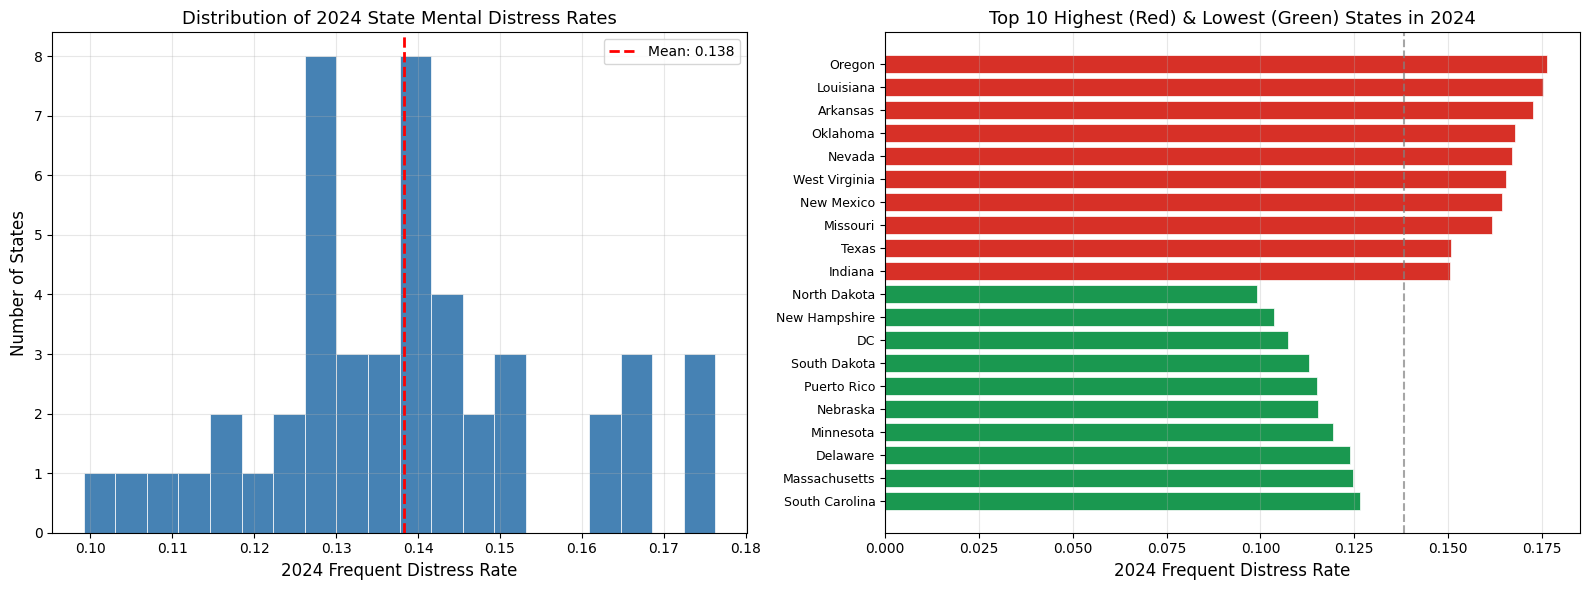

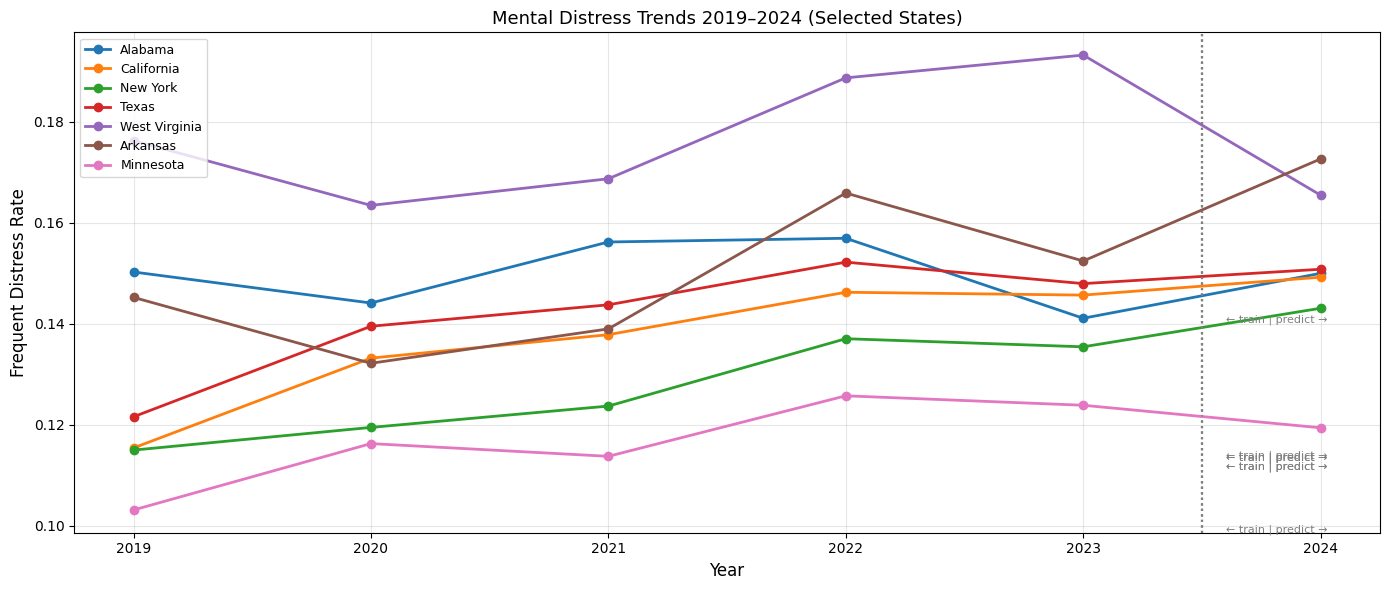

In [7]:
# CELL 6 — EDA: Mental Distress Trends by State

# Plot 2024 distress rate across states
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: distribution of 2024 rates
axes[0].hist(y_all, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(y_all.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {y_all.mean():.3f}')
axes[0].set_xlabel('2024 Frequent Distress Rate', fontsize=12)
axes[0].set_ylabel('Number of States', fontsize=12)
axes[0].set_title('Distribution of 2024 State Mental Distress Rates', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: top 10 and bottom 10 states
sorted_idx = np.argsort(y_all)
top10_idx = sorted_idx[-10:][::-1]
bot10_idx = sorted_idx[:10]
show_idx = np.concatenate([top10_idx, bot10_idx])
show_labels = [f"{fips_to_state.get(int(state_labels[i]), str(int(state_labels[i])))}"
               for i in show_idx]
show_vals = y_all[show_idx]
colors_bar = ['#d73027']*10 + ['#1a9850']*10

axes[1].barh(range(20), show_vals[::-1],
             color=colors_bar[::-1], edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(show_labels[::-1], fontsize=9)
axes[1].set_xlabel('2024 Frequent Distress Rate', fontsize=12)
axes[1].set_title('Top 10 Highest (Red) & Lowest (Green) States in 2024', fontsize=13)
axes[1].axvline(y_all.mean(), color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/state_distress_2024.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Trend lines for a sample of states
fig, ax = plt.subplots(figsize=(14, 6))
all_years = TRAIN_YEARS + [PRED_YEAR]
sample_states = [1, 6, 36, 48, 54, 5, 27]  # AL, CA, NY, TX, WV, AR, MN
cmap = cm.get_cmap('tab10')

for i, s in enumerate(sample_states):
    if s not in state_labels:
        continue
    idx = state_labels.index(s)
    state_data = df_agg[df_agg['_STATE'] == s].sort_values('SURVEY_YEAR')
    ys = [state_data[state_data['SURVEY_YEAR'] == yr]['FREQ_DISTRESS'].values[0]
          if yr in state_data['SURVEY_YEAR'].values else np.nan
          for yr in all_years]
    name = fips_to_state.get(s, str(s))
    ax.plot(all_years, ys, marker='o', linewidth=2, label=name, color=cmap(i))
    ax.axvline(2023.5, color='gray', linestyle=':', alpha=0.5)
    ax.text(2023.6, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.05,
            '← train | predict →', fontsize=8, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Frequent Distress Rate', fontsize=12)
ax.set_title('Mental Distress Trends 2019–2024 (Selected States)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/state_trends.png",
            dpi=150, bbox_inches='tight')
plt.show()


In [8]:
print(f"Features actually used ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  {f}")

Features actually used (24):
  PHYS_INACTIVE
  CURRENT_SMOKER
  BINGE_DRINK
  HEAVY_DRINK
  OVERWEIGHT_OBESE
  POOR_GENHLTH
  DEPRESSION_DX
  DIABETES
  HEART_ATTACK
  STROKE
  COPD
  ARTHRITIS
  NO_AFFORD_DR
  CHECKUP_RECENT
  HAS_DOCTOR
  FOOD_STAMPS
  ACE_SCORE
  ACE_HH_DYSFUNCTION
  HARDSHIP_ANY
  FOOD_INSECURE
  LOW_EMOTIONAL_SUPPORT
  LIFE_DISSATISFIED
  ACEADSAF_BIN
  ACEADNED_BIN


In [9]:
#CELL 7 — BASELINE MODEL 1: Linear Regression
# (Leave-One-State-Out Cross-Validation)

# For linear regression, we flatten the 5-year sequence into a single feature vector
# per state: [year1_feat1, year1_feat2, ..., year5_featN]
# n_timesteps × n_features = 5 × 26 = ~130 features

def run_loso_linear_regression(X_imp, y, state_lbls, scaler):
    """
    Leave-One-State-Out cross-validation for linear regression.
    Returns predictions and actuals aligned by state.
    """
    n = len(state_lbls)
    preds = np.zeros(n)

    # Flatten sequences: (n_states, 5, n_features) → (n_states, 5*n_features)
    X_flat = X_imp.reshape(n, -1)

    for i in range(n):
        # Hold out state i
        train_idx = [j for j in range(n) if j != i]
        test_idx  = [i]

        X_train = X_flat[train_idx]
        X_test  = X_flat[test_idx]
        y_train = y[train_idx]

        # Scale inside LOSO loop (no test leakage)
        sc = StandardScaler()
        X_train_sc = sc.fit_transform(X_train)
        X_test_sc  = sc.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_sc, y_train)
        preds[i] = model.predict(X_test_sc)[0]

    return preds

print("Running Linear Regression LOSO CV...")
lr_preds = run_loso_linear_regression(X_imputed, y_all, state_labels, scaler)

lr_mae  = mean_absolute_error(y_all, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_all, lr_preds))
lr_r, lr_p = pearsonr(y_all, lr_preds)

print(f"\nLinear Regression LOSO Results:")
print(f"  MAE:      {lr_mae:.4f}")
print(f"  RMSE:     {lr_rmse:.4f}")
print(f"  Pearson R:{lr_r:.4f}  (p={lr_p:.4f})")

#MAE of 0.02 means off by ~2 percentage points on distress rate
print(f"\n  Interpretation: On average, predictions are off by")
print(f"  {lr_mae*100:.2f} percentage points from actual 2024 state rates.")


Running Linear Regression LOSO CV...

Linear Regression LOSO Results:
  MAE:      0.0153
  RMSE:     0.0225
  Pearson R:0.4142  (p=0.0034)

  Interpretation: On average, predictions are off by
  1.53 percentage points from actual 2024 state rates.


In [11]:
# CELL 8 — BASELINE MODEL 2: ARIMA (per-state time series)
# ============================================================

# ARIMA treats each state as its own independent time series.
# Input: FREQ_DISTRESS rates for 2019-2023 (5 observations)
# Output: predicted 2024 rate
# Using auto_arima to automatically select best (p, d, q) order per state.

# Note: 5 observations is very short for ARIMA — we use simple orders (max p=2, d=1, q=1)
# This is why we use ARIMA as a baseline(it has no cross-state information.)

def run_arima_loso(df_agg_in, state_lbls, train_years, pred_year):
    """
    Fit one ARIMA model per state using only that state's time series.
    No cross-validation needed — ARIMA predicts the next step after training.
    """
    preds   = {}
    actuals = {}
    orders  = {}

    for state in state_lbls:
        state_data = df_agg_in[df_agg_in['_STATE'] == state].sort_values('SURVEY_YEAR')

        # Training series: 2019-2023
        train_series = state_data[state_data['SURVEY_YEAR'].isin(train_years)]['FREQ_DISTRESS'].values

        # Actual 2024
        actual = state_data[state_data['SURVEY_YEAR'] == pred_year]['FREQ_DISTRESS'].values
        if len(actual) == 0 or len(train_series) < 4:
            continue
        actuals[state] = actual[0]

        try:
            model = pm.auto_arima(
                train_series,
                start_p=0, max_p=2,
                start_q=0, max_q=1,
                d=None,          # auto-select differencing
                max_d=1,
                seasonal=False,  # no seasonal component (annual data, no seasonality)
                information_criterion='aic',
                suppress_warnings=True,
                error_action='ignore',
                stepwise=True,
            )
            forecast = model.predict(n_periods=1)[0]
            preds[state]  = forecast
            orders[state] = model.order
        except Exception as e:
            # Fallback: use last observed value (naïve forecast)
            preds[state]  = train_series[-1]
            orders[state] = 'fallback'

    return preds, actuals, orders

print("Running ARIMA per-state forecasting...")
arima_preds_dict, arima_actuals_dict, arima_orders = run_arima_loso(
    df_agg, state_labels, TRAIN_YEARS, PRED_YEAR
)

# Align arrays
common_states = [s for s in state_labels if s in arima_preds_dict and s in arima_actuals_dict]
arima_pred_arr   = np.array([arima_preds_dict[s]   for s in common_states])
arima_actual_arr = np.array([arima_actuals_dict[s] for s in common_states])

arima_mae  = mean_absolute_error(arima_actual_arr, arima_pred_arr)
arima_rmse = np.sqrt(mean_squared_error(arima_actual_arr, arima_pred_arr))
arima_r, arima_p = pearsonr(arima_actual_arr, arima_pred_arr)

print(f"\nARIMA LOSO Results ({len(common_states)} states):")
print(f"  MAE:      {arima_mae:.4f}")
print(f"  RMSE:     {arima_rmse:.4f}")
print(f"  Pearson R:{arima_r:.4f}  (p={arima_p:.4f})")

# Show most common ARIMA orders
from collections import Counter
order_counts = Counter(str(v) for v in arima_orders.values() if v != 'fallback')
print(f"\n  Most common ARIMA orders: {order_counts.most_common(5)}")
fallback_n = sum(1 for v in arima_orders.values() if v == 'fallback')
if fallback_n > 0:
    print(f"  Fallback (naïve) used for {fallback_n} states.")


Running ARIMA per-state forecasting...

ARIMA LOSO Results (48 states):
  MAE:      0.0116
  RMSE:     0.0137
  Pearson R:0.8007  (p=0.0000)

  Most common ARIMA orders: [('(0, 0, 0)', 41), ('(1, 0, 0)', 5), ('(0, 0, 1)', 2)]


In [12]:

# CELL 9 — BUILD POPULATION LSTM

def build_population_lstm(n_timesteps, n_features,
                           lstm_units_1=32, lstm_units_2=16,
                           dense_units=16, dropout=0.3):
    """
    Compact LSTM for state-level time series prediction.
    Small architecture appropriate for 50-state dataset.

    Architecture:
      Input → LSTM(32) → Dropout → LSTM(16) → Dropout
            → Dense(16, relu) → Dense(1, linear)
    """
    inp = Input(shape=(n_timesteps, n_features), name='state_sequence')

    # Masking layer handles the structural NaN → 0 fills
    x = layers.Masking(mask_value=0.0)(inp)

    # Two LSTM layers — first returns sequences for second to process
    x = layers.LSTM(lstm_units_1, return_sequences=True,
                    name='lstm_1')(x)
    x = layers.Dropout(dropout, name='drop_1')(x)
    x = layers.LSTM(lstm_units_2, return_sequences=False,
                    name='lstm_2')(x)
    x = layers.Dropout(dropout, name='drop_2')(x)

    # Dense head
    x = layers.Dense(dense_units, activation='relu', name='dense_1')(x)
    output = layers.Dense(1, activation='linear', name='output')(x)

    model = Model(inputs=inp, outputs=output, name='Population_LSTM')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Preview architecture
sample_model = build_population_lstm(
    n_timesteps=len(TRAIN_YEARS),
    n_features=len(FEATURE_COLS)
)
sample_model.summary()


Model: "Population_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_sequence      │ (None, 5, 24)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5, 24)     │          0 │ state_sequence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 5, 24)     │          0 │ state_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 5)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 5, 32)     │      7,296 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 5, 32)     │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 16)        │      3,136 │ drop_1[0][0],     │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 16)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        272 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,721 (41.88 KB)

 Trainable params: 10,721 (41.88 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# CELL 10 — POPULATION LSTM: Leave-One-State-Out CV

def scale_sequences(X_train, X_test):
    """Scale inside LOSO loop to prevent test data leakage."""
    n_tr, t, f = X_train.shape
    n_te = X_test.shape[0]
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train.reshape(-1, f)).reshape(n_tr, t, f)
    X_te_sc = sc.transform(X_test.reshape(-1, f)).reshape(n_te, t, f)
    return X_tr_sc, X_te_sc, sc

print("Running Population LSTM Leave-One-State-Out CV...")
print(f"Total folds: {len(state_labels)}\n")

lstm_preds   = np.zeros(len(state_labels))
lstm_actuals = y_all.copy()

for fold, held_out_idx in enumerate(range(len(state_labels))):

    train_idx = [j for j in range(len(state_labels)) if j != held_out_idx]

    X_train = X_imputed[train_idx]        # (49, 5, n_features)
    X_test  = X_imputed[[held_out_idx]]   # (1,  5, n_features)
    y_train = y_all[train_idx]            # (49,)
    y_test  = y_all[[held_out_idx]]       # (1,)

    # Scale inside fold
    X_train_sc, X_test_sc, _ = scale_sequences(X_train, X_test)

    # Build fresh model each fold (no weight leakage between folds)
    tf.random.set_seed(42 + fold)
    fold_model = build_population_lstm(
        n_timesteps=len(TRAIN_YEARS),
        n_features=len(FEATURE_COLS)
    )

    # Train with early stopping — short patience since dataset is tiny
    fold_model.fit(
        X_train_sc, y_train,
        epochs=200,
        batch_size=16,         # small batch for small dataset
        verbose=0,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=10, min_lr=1e-5),
        ],
        validation_split=0.1,  # ~5 states as validation within training set
    )

    pred = fold_model.predict(X_test_sc, verbose=0)[0][0]
    lstm_preds[held_out_idx] = pred

    # Progress every 10 folds
    if (fold + 1) % 10 == 0:
        partial_mae = mean_absolute_error(lstm_actuals[:fold+1], lstm_preds[:fold+1])
        state_name  = fips_to_state.get(int(state_labels[held_out_idx]), str(int(state_labels[held_out_idx])))
        print(f"  Fold {fold+1:2d}/50 — {state_name:<20} "
              f"Pred: {pred:.3f}  Actual: {y_test[0]:.3f}  "
              f"Running MAE: {partial_mae:.4f}")

# Final metrics
lstm_mae  = mean_absolute_error(lstm_actuals, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actuals, lstm_preds))
lstm_r, lstm_p = pearsonr(lstm_actuals, lstm_preds)

print(f"\nPopulation LSTM LOSO Results:")
print(f"  MAE:      {lstm_mae:.4f}")
print(f"  RMSE:     {lstm_rmse:.4f}")
print(f"  Pearson R:{lstm_r:.4f}  (p={lstm_p:.4f})")



Running Population LSTM Leave-One-State-Out CV...
Total folds: 48



  Fold 10/50 — Georgia              Pred: 0.182  Actual: 0.142  Running MAE: 0.0192
  Fold 20/50 — Massachusetts        Pred: 0.134  Actual: 0.125  Running MAE: 0.0221
  Fold 30/50 — New York             Pred: 0.064  Actual: 0.143  Running MAE: 0.0261
  Fold 40/50 — Utah                 Pred: 0.206  Actual: 0.141  Running MAE: 0.0274

Population LSTM LOSO Results:
  MAE:      0.0259
  RMSE:     0.0346
  Pearson R:0.3474  (p=0.0156)


In [14]:
# CELL 11 — MODEL COMPARISON TABLE
# ============================================================

print("=" * 60)
print("STUDY A — MODEL COMPARISON (Population-Level)")
print("=" * 60)
print(f"\n{'Model':<25} | {'MAE':>8} | {'RMSE':>8} | {'Pearson R':>10} | {'Beats LR?':>10}")
print("-" * 68)

results = {
    'Linear Regression': (lr_mae, lr_rmse, lr_r),
    'ARIMA':             (arima_mae, arima_rmse, arima_r),
    'Population LSTM':   (lstm_mae, lstm_rmse, lstm_r),
}

lr_baseline_mae = lr_mae
for name, (mae, rmse, r) in results.items():
    beats = '✓' if name != 'Linear Regression' and mae < lr_baseline_mae else ('—' if name == 'Linear Regression' else '✗')
    print(f"  {name:<23} | {mae:>8.4f} | {rmse:>8.4f} | {r:>10.4f} | {beats:>10}")

print()
print("Notes:")
print("  MAE = Mean Absolute Error on 2024 state distress rate predictions")
print("  Pearson R = correlation between predicted and actual 2024 rates")
print("  All models evaluated via Leave-One-State-Out CV (50 folds)")
print()

# Interpretation
print("  In context: MAE of 0.02 means predictions are off by ~2 pp")
print("  (e.g., predicts 14.5% when actual is 16.5%)")
print()
if lstm_mae < lr_mae:
    improvement = (lr_mae - lstm_mae) / lr_mae * 100
    print(f"  ✓ Population LSTM improves on LR baseline by {improvement:.1f}% in MAE")
else:
    print(f"  ✗ LSTM does not outperform LR — honest finding worth reporting.")
    print(f"    Likely reason: 50 sequences is too small for LSTM to generalize.")
    print(f"    Report this transparently — it validates why individual-level")
    print(f"    modeling (Study B) is the stronger approach for this dataset.")


STUDY A — MODEL COMPARISON (Population-Level)

Model                     |      MAE |     RMSE |  Pearson R |  Beats LR?
--------------------------------------------------------------------
  Linear Regression       |   0.0153 |   0.0225 |     0.4142 |          —
  ARIMA                   |   0.0116 |   0.0137 |     0.8007 |          ✓
  Population LSTM         |   0.0259 |   0.0346 |     0.3474 |          ✗

Notes:
  MAE = Mean Absolute Error on 2024 state distress rate predictions
  Pearson R = correlation between predicted and actual 2024 rates
  All models evaluated via Leave-One-State-Out CV (50 folds)

  In context: MAE of 0.02 means predictions are off by ~2 pp
  (e.g., predicts 14.5% when actual is 16.5%)

  ✗ LSTM does not outperform LR — honest finding worth reporting.
    Likely reason: 50 sequences is too small for LSTM to generalize.
    Report this transparently — it validates why individual-level
    modeling (Study B) is the stronger approach for this dataset.


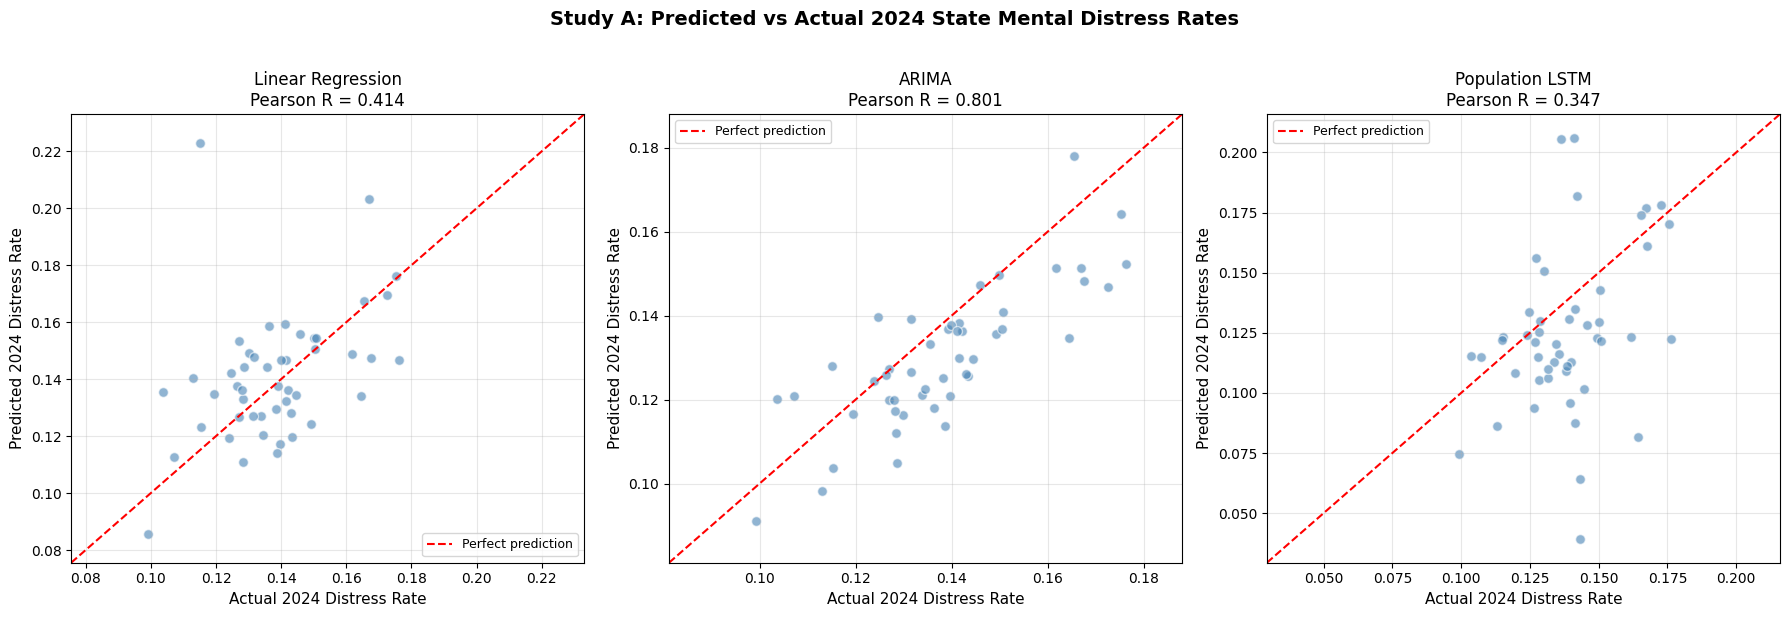

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_data = [
    ('Linear Regression', lr_preds,    y_all,            lr_r),
    ('ARIMA',             arima_pred_arr, arima_actual_arr, arima_r),
    ('Population LSTM',   lstm_preds,  lstm_actuals,     lstm_r),
]

for ax, (name, preds, actuals, r) in zip(axes, model_data):
    ax.scatter(actuals, preds, alpha=0.6, s=50, color='steelblue', edgecolors='white')
    # Perfect prediction line
    lims = [min(actuals.min(), preds.min()) - 0.01,
            max(actuals.max(), preds.max()) + 0.01]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual 2024 Distress Rate', fontsize=11)
    ax.set_ylabel('Predicted 2024 Distress Rate', fontsize=11)
    ax.set_title(f'{name}\nPearson R = {r:.3f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle('Study A: Predicted vs Actual 2024 State Mental Distress Rates',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/studyA_pred_vs_actual.png",
            dpi=150, bbox_inches='tight')
plt.show()



COVID-Era Temporal Analysis

States with LARGEST COVID spike (2019→2021):
       name  pre_covid_2019  covid_peak_2021  post_2024  covid_spike
     Nevada        0.135636         0.162202   0.167052     0.026566
   Colorado        0.104696         0.130511   0.139163     0.025815
     Oregon        0.134914         0.158055   0.176305     0.023141
 California        0.115438         0.137848   0.149214     0.022410
Connecticut        0.099590         0.121933   0.139614     0.022344

States that RECOVERED most by 2024 (largest decrease from peak):
         name  covid_peak_2021  post_2024  recovery
Massachusetts         0.135361   0.124731 -0.010630
      Alabama         0.156181   0.149980 -0.006201
New Hampshire         0.108276   0.103649 -0.004628
           DC         0.110827   0.107222 -0.003605
West Virginia         0.168686   0.165440 -0.003246

States with WORST persistent distress (2024 rate):
     name  pre_covid_2019  covid_peak_2021  post_2024
   Oregon        0.134914   

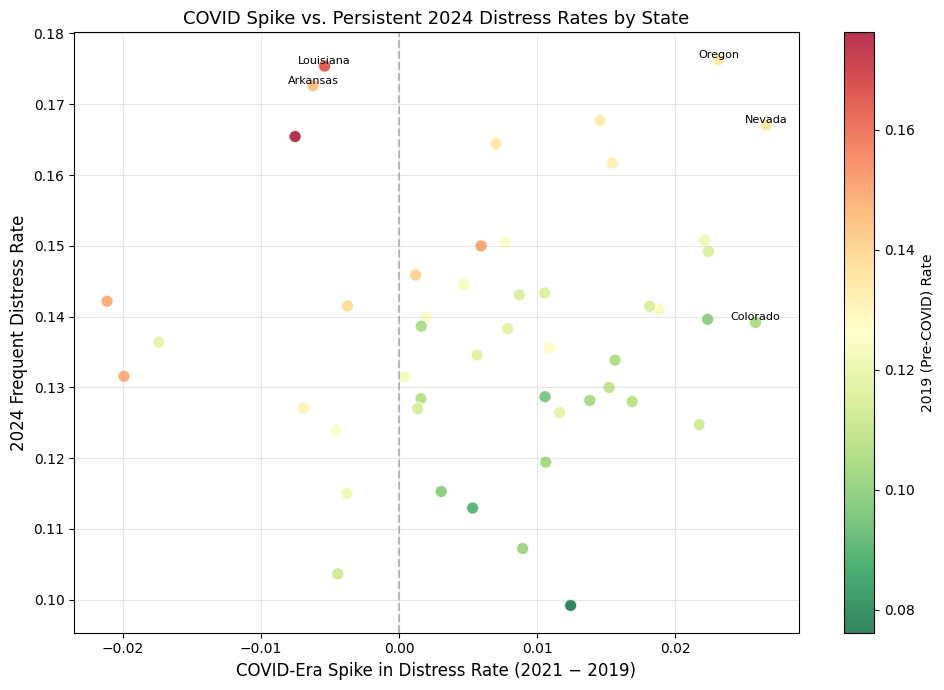

In [16]:
# CELL 13 — COVID TEMPORAL ANALYSIS
# ============================================================
# Key narrative: did states that saw bigger COVID-era spikes (2020-2021)
# show persistently elevated distress rates through 2024?

print("COVID-Era Temporal Analysis")
print("=" * 50)

# Compute COVID spike = 2021 rate - 2019 rate for each state
covid_analysis = []
for state in state_labels:
    state_data = df_agg[df_agg['_STATE'] == state].sort_values('SURVEY_YEAR')
    pre_covid = state_data[state_data['SURVEY_YEAR'] == 2019]['FREQ_DISTRESS'].values
    covid_peak = state_data[state_data['SURVEY_YEAR'] == 2021]['FREQ_DISTRESS'].values
    post_covid = state_data[state_data['SURVEY_YEAR'] == 2024]['FREQ_DISTRESS'].values

    if len(pre_covid) and len(covid_peak) and len(post_covid):
        spike    = float(covid_peak[0]) - float(pre_covid[0])
        recovery = float(post_covid[0]) - float(covid_peak[0])
        covid_analysis.append({
            'state': state,
            'name': fips_to_state.get(int(state), str(int(state))),
            'pre_covid_2019':  float(pre_covid[0]),
            'covid_peak_2021': float(covid_peak[0]),
            'post_2024':       float(post_covid[0]),
            'covid_spike':     spike,
            'recovery':        recovery,   # negative = improved, positive = got worse
        })

df_covid = pd.DataFrame(covid_analysis)

print(f"\nStates with LARGEST COVID spike (2019→2021):")
print(df_covid.nlargest(5, 'covid_spike')[['name','pre_covid_2019','covid_peak_2021','post_2024','covid_spike']].to_string(index=False))

print(f"\nStates that RECOVERED most by 2024 (largest decrease from peak):")
print(df_covid.nsmallest(5, 'recovery')[['name','covid_peak_2021','post_2024','recovery']].to_string(index=False))

print(f"\nStates with WORST persistent distress (2024 rate):")
print(df_covid.nlargest(5, 'post_2024')[['name','pre_covid_2019','covid_peak_2021','post_2024']].to_string(index=False))

# Scatter: COVID spike vs 2024 distress rate
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df_covid['covid_spike'], df_covid['post_2024'],
                     c=df_covid['pre_covid_2019'],
                     cmap='RdYlGn_r', s=80, alpha=0.8, edgecolors='white')
plt.colorbar(scatter, ax=ax, label='2019 (Pre-COVID) Rate')

# Label extreme states
for _, row in pd.concat([df_covid.nlargest(3,'post_2024'),
                          df_covid.nlargest(3,'covid_spike')]).drop_duplicates().iterrows():
    ax.annotate(row['name'], (row['covid_spike'], row['post_2024']),
                fontsize=8, ha='center', va='bottom')

ax.set_xlabel('COVID-Era Spike in Distress Rate (2021 − 2019)', fontsize=12)
ax.set_ylabel('2024 Frequent Distress Rate', fontsize=12)
ax.set_title('COVID Spike vs. Persistent 2024 Distress Rates by State', fontsize=13)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/covid_spike_vs_2024.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# CELL 14 — CHOROPLETH MAP (US State-Level Predictions)
# ============================================================

import plotly.graph_objects as go
import plotly.express as px

# Build dataframe for map
map_df = pd.DataFrame({
    'state_fips': [int(s) for s in state_labels],
    'state_name': [fips_to_state.get(int(s), str(int(s))) for s in state_labels],
    'actual_2024':   y_all,
    'pred_lstm_2024': lstm_preds,
    'pred_lr_2024':   lr_preds,
    'error_lstm': lstm_preds - y_all,
    'error_lr':   lr_preds - y_all,
})

# Add COVID spike
map_df = map_df.merge(df_covid[['state','covid_spike']].rename(columns={'state':'state_fips'}),
                       on='state_fips', how='left')

# Actual 2024 rate choropleth
fig = px.choropleth(
    map_df,
    locations='state_fips',
    locationmode='USA-states',
    color='actual_2024',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    range_color=[map_df['actual_2024'].min(), map_df['actual_2024'].max()],
    labels={'actual_2024': 'Distress Rate'},
    title='2024 Frequent Mental Distress Rate by State (Actual)',
    hover_name='state_name',
    hover_data={'actual_2024': ':.3f', 'state_fips': False},
)
fig.update_layout(geo=dict(showlakes=True, lakecolor='lightblue'))
fig.write_html(f"{PROJECT_PATH}/clean_data/choropleth_actual_2024.html")
fig.show()

# LSTM prediction error map
fig2 = px.choropleth(
    map_df,
    locations='state_fips',
    locationmode='USA-states',
    color='error_lstm',
    scope='usa',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    labels={'error_lstm': 'Prediction Error'},
    title='Population LSTM Prediction Error by State (Predicted − Actual)',
    hover_name='state_name',
    hover_data={'error_lstm': ':.3f', 'actual_2024': ':.3f', 'pred_lstm_2024': ':.3f'},
)
fig2.write_html(f"{PROJECT_PATH}/clean_data/choropleth_lstm_error.html")
fig2.show()


In [18]:
# CELL 15 — SAVE ALL RESULTS
# ============================================================

import pickle

study_a_results = {
    # Predictions
    'state_labels':    state_labels,
    'y_actual_2024':   y_all,
    'lr_preds':        lr_preds,
    'arima_preds':     arima_pred_arr,
    'lstm_preds':      lstm_preds,

    # Metrics
    'metrics': {
        'Linear Regression': {'mae': lr_mae,   'rmse': lr_rmse,   'pearson_r': lr_r},
        'ARIMA':             {'mae': arima_mae, 'rmse': arima_rmse,'pearson_r': arima_r},
        'Population LSTM':   {'mae': lstm_mae,  'rmse': lstm_rmse, 'pearson_r': lstm_r},
    },

    # COVID analysis
    'covid_df': df_covid,

    # Metadata
    'feature_cols':  FEATURE_COLS,
    'train_years':   TRAIN_YEARS,
    'pred_year':     PRED_YEAR,
    'n_states':      len(state_labels),
    'fips_to_state': fips_to_state,
}

with open(f"{PROJECT_PATH}/clean_data/study_a_results.pkl", 'wb') as f:
    pickle.dump(study_a_results, f)

# Also save as CSV for easy sharing with team
results_df = pd.DataFrame({
    'state_fips': [int(s) for s in state_labels],
    'state_name': [fips_to_state.get(int(s), str(int(s))) for s in state_labels],
    'actual_2024':       y_all,
    'lr_pred':           lr_preds,
    'arima_pred':        arima_pred_arr if len(arima_pred_arr) == len(state_labels)
                         else [arima_preds_dict.get(s, np.nan) for s in state_labels],
    'lstm_pred':         lstm_preds,
    'lr_error':          lr_preds - y_all,
    'lstm_error':        lstm_preds - y_all,
})
results_df.to_csv(f"{PROJECT_PATH}/clean_data/study_a_predictions.csv", index=False)

print(f"   study_a_results.pkl         — full results dict (for Gia's SHAP/report)")
print(f"   study_a_predictions.csv     — predictions table (easy to share/inspect)")
print(f"   state_distress_2024.png     — distribution + bar chart")
print(f"   state_trends.png            — trend lines for selected states")
print(f"   studyA_pred_vs_actual.png   — pred vs actual scatter (3 models)")
print(f"   covid_spike_vs_2024.png     — COVID spike analysis scatter")
print(f"   choropleth_actual_2024.html — interactive US map (actual)")
print(f"   choropleth_lstm_error.html  — interactive US map (LSTM error)")

print(f"\n{'='*55}")
print(f"STUDY A COMPLETE")
print(f"{'='*55}")
print(f"\nFinal Summary:")
for name, m in study_a_results['metrics'].items():
    print(f"  {name:<25} MAE={m['mae']:.4f}  R={m['pearson_r']:.3f}")

   study_a_results.pkl         — full results dict (for Gia's SHAP/report)
   study_a_predictions.csv     — predictions table (easy to share/inspect)
   state_distress_2024.png     — distribution + bar chart
   state_trends.png            — trend lines for selected states
   studyA_pred_vs_actual.png   — pred vs actual scatter (3 models)
   covid_spike_vs_2024.png     — COVID spike analysis scatter
   choropleth_actual_2024.html — interactive US map (actual)
   choropleth_lstm_error.html  — interactive US map (LSTM error)

STUDY A COMPLETE

Final Summary:
  Linear Regression         MAE=0.0153  R=0.414
  ARIMA                     MAE=0.0116  R=0.801
  Population LSTM           MAE=0.0259  R=0.347
